In [77]:
import pandas as pd

import matplotlib.pyplot as plt

In [78]:
df = pd.read_csv('data/train.csv')

df_final = pd.read_csv('data/test.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [79]:
df.shape

(891, 12)

In [80]:
# Separando as varievias preditoras e nosso alvo
X = df.drop(columns=['PassengerId', 'Survived'])

y = df['Survived'].copy()

# Seprando treino e teste mantendo a mesma proporção do nosso alvo
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    stratify=y,
                                                    random_state=42)

# Conferindo as proporçãos 
print('Base original',df['Survived'].mean())
print('Base treino',y_train.mean())
print('Base treino',y_test. mean())


Base original 0.3838383838383838
Base treino 0.38362760834670945
Base treino 0.3843283582089552


In [81]:
# Analise descritiva 
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [83]:
# Olhando a quantidade de valores unicos de cada variavel 
valores_unicos = []

for i in df.columns[:].to_list():
    print(i,':', len(df[i].astype(str).value_counts()))

PassengerId : 891
Survived : 2
Pclass : 3
Name : 891
Sex : 2
Age : 89
SibSp : 7
Parch : 7
Ticket : 681
Fare : 248
Cabin : 148
Embarked : 4


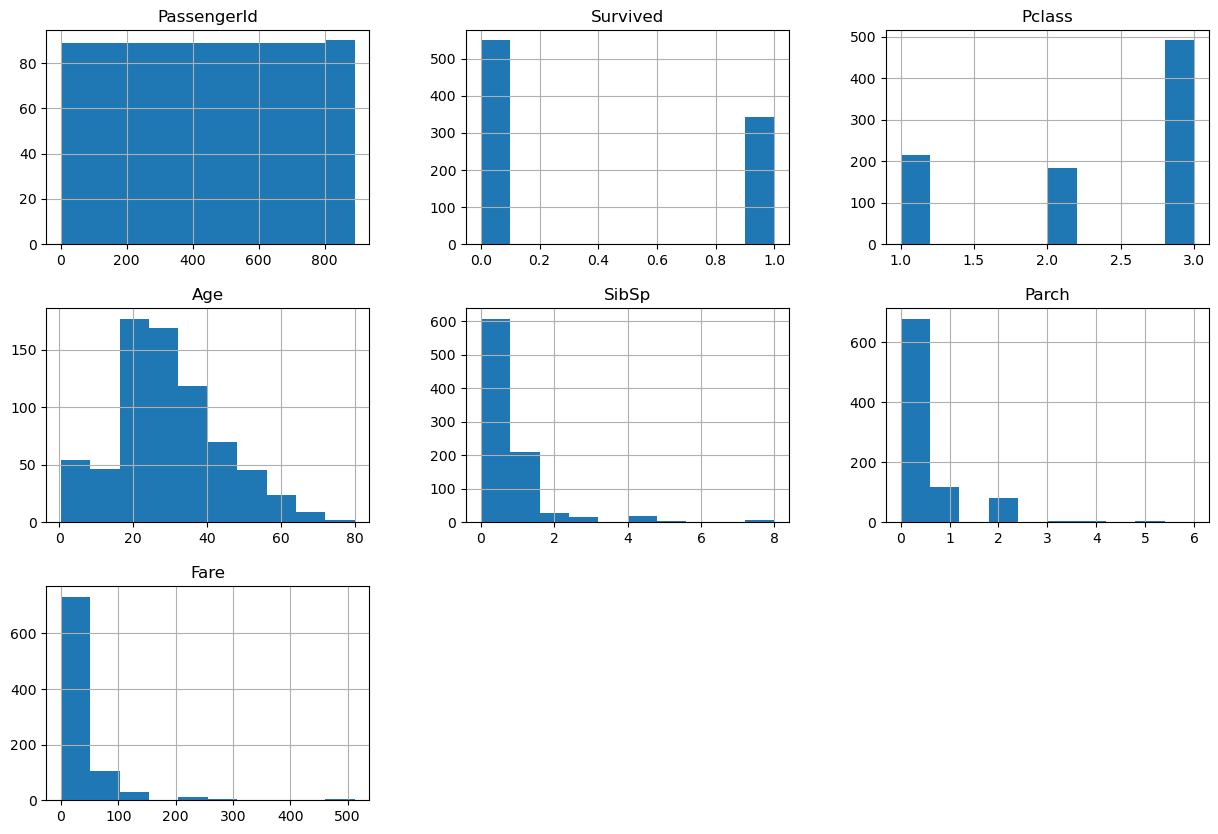

In [84]:
# Plotando um histograma para ver a distribuição das varievais numericas 
df.hist(figsize=(15, 10))

plt.show()

In [85]:
# Olhando as relação das variveis 
corr = df.corr(numeric_only=True)

corr['Survived'].sort_values(ascending=False)

Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64

In [86]:
# Quantidade de valores ausentes em cada variavel 
df.isna().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

In [ ]:
# Olhando os tipos de dados e valores faltantes 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# Vendo as features para testar novas combinações 
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [90]:
# Testando ideis de variveis para criação de novas features 
df.groupby(['Sex', df['SibSp'] <= 2])['Survived'].mean()

Sex     SibSp
female  False    0.285714
        True     0.774744
male    False    0.040000
        True     0.195652
Name: Survived, dtype: float64

In [91]:
# Testando se quem tem cabine preenchida tende a sobrevivier 
df.groupby([df['Cabin'].notna()])['Survived'].mean()

Cabin
False    0.299854
True     0.666667
Name: Survived, dtype: float64

In [ ]:
# Testando as idades 

In [ ]:
# Criando uma função para tratamentos dos dados
def tratamento_cricao_features(df):
    
    df = df.copy()

    # Preenchendo idade pela média
    df['Age'] = df['Age'].fillna(df['Age'].mean())

    # Preenchendo Embarked pela moda 
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    # Tratando valores categoricos 
    df['Sex'] = df['Sex'].map({
        'male': 0,
        'female': 1,
    })

    # Fazendo um onehot enconder para Embarked
    df = pd.get_dummies(df,
        columns=['Embarked'],
        dtype=int
    )

    # Criação de features 

    # Tem cabine preebchida ou não 
    df['Tem_cabine_preenchida'] = df['Cabin'].notna().astype(int)

    # Posuei familia pequena 
    df['Sibsp_pequeno'] = (df['SibSp'] <= 2).astype(int)

    # Mulheres com familia pequena
    df['Mulher_Sibsp_pequeno'] = ((df['Sex'] == 1) & (df['SibSp'] <= 2))

    return df

# Criando uma nova DF e aplicando para o treino e teste 
df_tratada = tratamento_cricao_features(df)

#X_train = tratamento(X_train)
#X_test = tratamento(X_test)

# Verificando o tratamento 
df_tratada.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   PassengerId            891 non-null    int64  
 1   Survived               891 non-null    int64  
 2   Pclass                 891 non-null    int64  
 3   Name                   891 non-null    object 
 4   Sex                    891 non-null    int64  
 5   Age                    891 non-null    float64
 6   SibSp                  891 non-null    int64  
 7   Parch                  891 non-null    int64  
 8   Ticket                 891 non-null    object 
 9   Fare                   891 non-null    float64
 10  Cabin                  204 non-null    object 
 11  Embarked_C             891 non-null    int32  
 12  Embarked_Q             891 non-null    int32  
 13  Embarked_S             891 non-null    int32  
 14  Tem_cabine_preenchida  891 non-null    int32  
 15  Sibsp_

In [93]:
# Verificando a correlação das features criadas e outras existente
corr = df_tratada.corr(numeric_only=True)['Survived'].sort_values(ascending=False)

corr

Survived                 1.000000
Mulher_Sibsp_pequeno     0.562644
Sex                      0.543351
Tem_cabine_preenchida    0.316912
Fare                     0.257307
Embarked_C               0.168240
Sibsp_pequeno            0.111145
Parch                    0.081629
Embarked_Q               0.003650
PassengerId             -0.005007
SibSp                   -0.035322
Age                     -0.069809
Embarked_S              -0.149683
Pclass                  -0.338481
Name: Survived, dtype: float64

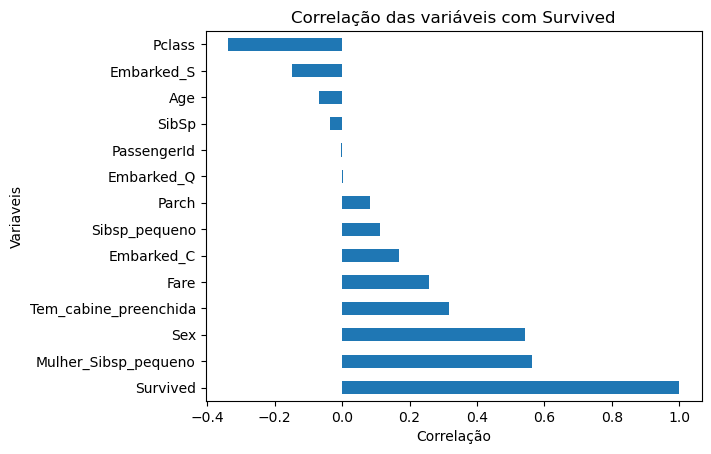

In [95]:
# Plotando a importancia 
corr.plot(
    kind='barh',
)

plt.title('Correlação das variáveis com Survived')

plt.xlabel('Correlação')

plt.ylabel('Variaveis')

plt.show()